# Pseudomonas syringae — Transfer Learning Pipeline
## 20-patch TL vs 10-patch TL

| Fix # | Problem | Correction |
|---|---|---|
| #1 | Severity score from `img_id` order → leakage | Single score per day |
| #2 | Only FC layer open | Layer4 + FC open |
| #3 | `input_size` silently changed | `DenoiserLSTM(input_size)` is parametric |
| #4 | Day12=0.40 (Xanthomonas anchor) | Day12=0.55 (Pseudomonas rapid-onset) |
| #5 | Chronological split → last days in val | `train_test_split` random patch split |
| #6 | lr=5e-5 + wd=1e-3 → train≈0, val explodes | lr=1e-4, wd=1e-4, early stopping |
| #7 | `build_lstm_tensors` global `target_series` | Each pipeline uses its own target |
| #8 | `plot_time`/`plot_target`/`eval_cnn_loader` undefined | All variables within a single pipeline |
| NEW | No patch visualization | Example patch grid for each day |

In [1]:
# Mounts Google Drive to the Colab environment; files can be
# accessed via /content/drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!unzip -q "/content/drive/MyDrive/archive.zip" -d "/content/dataset/"
!nvidia-smi

replace /content/dataset/01_11_2022/01_11_2022/01_11_2022_IMG_000046.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace /content/dataset/01_11_2022/01_11_2022/01_11_2022_IMG_000046.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Wed May  6 22:25:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off 

In [5]:
import glob
import os
import random
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
from scipy.optimize import curve_fit
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# ImageNet normalisation constants for pre-trained ResNet backbone.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Target device for model training and inference.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

NORMALIZE = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

# Root paths for dataset and saved model checkpoints on Google Drive.
DRIVE = '/content/drive/MyDrive/'
DRIVE_MODELS = '/content/drive/MyDrive/Transfer_2/'
DATASET = '/content/dataset/'

# Sliding window size for LSTM sequence construction.
WINDOW = 5

# Full paths for CNN and LSTM model checkpoints (20-sample and 10-sample).
CNN_20_PATH = DRIVE_MODELS + 'cnn_sensor_base_model_20.pth'
LSTM_20_PATH = DRIVE_MODELS + 'lstm_denoiser_base_model_20.pth'
CNN_10_PATH = DRIVE_MODELS + 'cnn_sensor_base_model_10.pth'
LSTM_10_PATH = DRIVE_MODELS + 'lstm_denoiser_base_model_10.pth'

# Verify that all required model checkpoint files exist on Drive.
print(f'Device: {DEVICE}')
for p in [CNN_20_PATH, LSTM_20_PATH, CNN_10_PATH, LSTM_10_PATH]:
    status = 'OK' if os.path.exists(p) else 'MISSING'
    print(f'  {status:6s}  {os.path.basename(p)}')

Device: cuda
  OK      cnn_sensor_base_model_20.pth
  OK      lstm_denoiser_base_model_20.pth
  OK      cnn_sensor_base_model_10.pth
  OK      lstm_denoiser_base_model_10.pth


In [6]:
import glob
import os
import random
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
from scipy.optimize import curve_fit
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# ImageNet normalisation constants for pre-trained ResNet backbone.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Target device for model training and inference.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

NORMALIZE = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

# Root paths for dataset and saved model checkpoints on Google Drive.
DRIVE = '/content/drive/MyDrive/'
DRIVE_MODELS = '/content/drive/MyDrive/Transfer_2/'
DATASET = '/content/dataset/'

# Sliding window size for LSTM sequence construction.
WINDOW = 3

# Full paths for CNN and LSTM model checkpoints (20-sample and 10-sample).
CNN_20_PATH = DRIVE_MODELS + 'cnn_sensor_base_model_20.pth'
LSTM_20_PATH = DRIVE_MODELS + 'lstm_denoiser_base_model_20.pth'
CNN_10_PATH = DRIVE_MODELS + 'cnn_sensor_base_model_10.pth'
LSTM_10_PATH = DRIVE_MODELS + 'lstm_denoiser_base_model_10.pth'

# Transfer LSTM architecture config — controls model instantiation.
# Change these values here only; do not hardcode elsewhere.
LSTM_INPUT_SIZE = 1     # CNN score only; no time index to prevent leakage
LSTM_HIDDEN_SIZE = 32
LSTM_NUM_LAYERS = 2
LSTM_DROPOUT = 0.2

# Base model architecture dimensions — must match the saved checkpoints.
# Run the size check below to verify alignment before loading weights.
X_LSTM_INPUT_SIZE = 1
X_LSTM_HIDDEN_SIZE = 32


def check_lstm_checkpoint(name, path, expected_input, expected_hidden):
    """
    Verify that a saved LSTM checkpoint matches the expected architecture.

    Reads weight matrix shapes directly from the state dict to infer
    actual input size, hidden size, and number of layers.

    Parameters:
        name            (str): Display label for the checkpoint (e.g. 'LSTM-20').
        path            (str): Filesystem path to the .pth checkpoint file.
        expected_input  (int): Expected LSTM input size.
        expected_hidden (int): Expected LSTM hidden size.

    Returns:
        bool: True if checkpoint matches expected dimensions, else False.
    """
    if not os.path.exists(path):
        print(f'  {name}: SKIPPED (file missing)')
        return False

    state_dict = torch.load(path, map_location='cpu')
    ih = state_dict['lstm.weight_ih_l0'].shape  # Shape: (4*hidden, input_size)
    actual_input = ih[1]
    actual_hidden = ih[0] // 4
    actual_layers = sum(
        1 for k in state_dict if k.startswith('lstm.weight_ih')
    )

    is_match = (
        actual_input == expected_input and
        actual_hidden == expected_hidden
    )
    status = "✓ OK" if is_match else "✗ MISMATCH"

    print(f'  {name} [{status}]')
    print(
        f'    Saved  → input_size={actual_input}, '
        f'hidden={actual_hidden}, num_layers={actual_layers}'
    )
    print(
        f'    Config → X_LSTM_INPUT_SIZE={expected_input}, '
        f'X_LSTM_HIDDEN_SIZE={expected_hidden}'
    )

    if not is_match:
        if actual_input != expected_input:
            print(f'    ► Fix: set X_LSTM_INPUT_SIZE  = {actual_input}')
        if actual_hidden != expected_hidden:
            print(f'    ► Fix: set X_LSTM_HIDDEN_SIZE = {actual_hidden}')

    return is_match


def check_cnn_checkpoint(name, path):
    """
    Verify that a saved CNN checkpoint contains the expected ResNet-18 head.

    Parameters:
        name (str): Display label for the checkpoint (e.g. 'CNN-20').
        path (str): Filesystem path to the .pth checkpoint file.

    Returns:
        bool: True if the checkpoint exists and is readable, else False.
    """
    if not os.path.exists(path):
        print(f'  {name}: SKIPPED (file missing)')
        return False

    state_dict = torch.load(path, map_location='cpu')
    fc_shape = state_dict['backbone.fc.weight'].shape  # Expected: (1, in_features)
    print(f'  {name} ✓  fc.weight={fc_shape}  (ResNet-18 standard)')
    return True


# Run all pre-flight checks and report results.
print(f'Device: {DEVICE}\n')
all_ok = True

# Check that all checkpoint files exist on Drive.
print("── File Check ───────────────────────────────────────")
for p in [CNN_20_PATH, LSTM_20_PATH, CNN_10_PATH, LSTM_10_PATH]:
    exists = os.path.exists(p)
    status = '✓' if exists else '✗ MISSING'
    print(f'  {status:8s}  {os.path.basename(p)}')
    if not exists:
        all_ok = False

# Verify LSTM checkpoint dimensions against expected config.
print("\n── LSTM Size Check ──────────────────────────────────")
for name, path in [("LSTM-20", LSTM_20_PATH), ("LSTM-10", LSTM_10_PATH)]:
    ok = check_lstm_checkpoint(
        name, path, X_LSTM_INPUT_SIZE, X_LSTM_HIDDEN_SIZE
    )
    all_ok = all_ok and ok

# Verify CNN checkpoint head dimensions.
print("\n── CNN Size Check ───────────────────────────────────")
for name, path in [("CNN-20", CNN_20_PATH), ("CNN-10", CNN_10_PATH)]:
    ok = check_cnn_checkpoint(name, path)
    all_ok = all_ok and ok

# Display transfer LSTM configuration summary.
print("\n── Transfer LSTM Configuration ──────────────────────")
print(f'  input_size  = {LSTM_INPUT_SIZE}')
print(f'  hidden_size = {LSTM_HIDDEN_SIZE}')
print(f'  num_layers  = {LSTM_NUM_LAYERS}')
print(f'  dropout     = {LSTM_DROPOUT}')

print()
if all_ok:
    print("✓ All checks passed — ready to run.")
else:
    print("✗ Issues detected — fix config before continuing.")

Device: cuda

── File Check ───────────────────────────────────────
  ✓         cnn_sensor_base_model_20.pth
  ✓         lstm_denoiser_base_model_20.pth
  ✓         cnn_sensor_base_model_10.pth
  ✓         lstm_denoiser_base_model_10.pth

── LSTM Size Check ──────────────────────────────────
  LSTM-20 [✓ OK]
    Saved  → input_size=1, hidden=32, num_layers=2
    Config → X_LSTM_INPUT_SIZE=1, X_LSTM_HIDDEN_SIZE=32
  LSTM-10 [✓ OK]
    Saved  → input_size=1, hidden=32, num_layers=2
    Config → X_LSTM_INPUT_SIZE=1, X_LSTM_HIDDEN_SIZE=32

── CNN Size Check ───────────────────────────────────
  CNN-20 ✓  fc.weight=torch.Size([1, 512])  (ResNet-18 standard)
  CNN-10 ✓  fc.weight=torch.Size([1, 512])  (ResNet-18 standard)

── Transfer LSTM Configuration ──────────────────────
  input_size  = 1
  hidden_size = 32
  num_layers  = 2
  dropout     = 0.2

✓ All checks passed — ready to run.


## 1. Model Classes

In [7]:
class FastRamDataset(Dataset):
    """
    In-memory dataset for patch-based disease severity regression.

    Parameters:
        patches (np.ndarray): Image patches of shape (N, H, W, 3).
        labels  (np.ndarray): Severity score labels of shape (N,).
    """

    def __init__(self, patches, labels):
        self.patches = patches
        self.labels = labels

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        # Convert patch from (H, W, C) to (C, H, W) for PyTorch convention.
        x = torch.from_numpy(self.patches[idx]).permute(2, 0, 1)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y


class PatchSeverityNet(nn.Module):
    """
    ResNet-18 based regression model for patch-level disease severity scoring.

    Replaces the default classification head with a single linear output unit.
    Raw logits are returned (no sigmoid) for compatibility with
    BCEWithLogitsLoss used during training.

    Parameters:
        pretrained (bool): If True, initialise backbone with ImageNet weights.
    """

    def __init__(self, pretrained=False):
        super().__init__()
        weights = 'IMAGENET1K_V1' if pretrained else None
        self.backbone = models.resnet18(weights=weights)
        # Replace classification head with a single regression output.
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, 1)

    def forward(self, x):
        return self.backbone(x).squeeze(1)  # Output shape: (batch,)


class DenoiserLstm(nn.Module):
    """
    Two-layer LSTM denoiser that maps noisy CNN score sequences to
    smoothed theoretical logistic severity values.

    Parameters:
        input_size  (int): Number of input features per time step.
        hidden_size (int): Number of hidden units in each LSTM layer.
    """

    def __init__(self, input_size=LSTM_INPUT_SIZE, hidden_size=LSTM_HIDDEN_SIZE):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=LSTM_NUM_LAYERS,
            dropout=LSTM_DROPOUT,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)  # Single regression output

    def forward(self, x):
        out, _ = self.lstm(x)
        # Use the last time step's hidden state for prediction.
        return torch.sigmoid(self.fc(out[:, -1, :])).squeeze(1)


def load_cnn(path, freeze_mode='partial'):
    """
    Load a PatchSeverityNet checkpoint and apply a freezing strategy.

    Freeze modes:
        'full'    — all parameters frozen (inference only).
        'partial' — all layers frozen except layer4 and fc (fine-tuning).

    Parameters:
        path        (str): Path to the saved .pth checkpoint.
        freeze_mode (str): One of 'full', 'partial', or None (all trainable).

    Returns:
        PatchSeverityNet: Model loaded with weights and freeze mode applied.
    """
    model = PatchSeverityNet(pretrained=False).to(DEVICE)
    model.load_state_dict(torch.load(path, map_location=DEVICE))

    if freeze_mode == 'full':
        for param in model.parameters():
            param.requires_grad = False
    elif freeze_mode == 'partial':
        # Freeze all layers first, then unfreeze layer4 and fc for fine-tuning.
        # layer3 remains frozen — sufficient capacity for 15-day transfer data.
        for param in model.parameters():
            param.requires_grad = False
        for block in [model.backbone.layer4, model.backbone.fc]:
            for param in block.parameters():
                param.requires_grad = True

    num_trainable = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )
    num_total = sum(p.numel() for p in model.parameters())
    print(
        f'  {os.path.basename(path)} | '
        f'trainable={num_trainable:,}/{num_total:,} '
        f'({100 * num_trainable / num_total:.1f}%)'
    )
    return model


def load_lstm(path, input_size=LSTM_INPUT_SIZE,
              hidden_size=LSTM_HIDDEN_SIZE, freeze_all=False):
    """
    Load a DenoiserLstm checkpoint with optional full parameter freezing.

    Parameters:
        path        (str): Path to the saved .pth checkpoint.
        input_size  (int): LSTM input size (must match the saved checkpoint).
        hidden_size (int): LSTM hidden size (must match the saved checkpoint).
        freeze_all  (bool): If True, freeze all parameters for inference only.

    Returns:
        DenoiserLstm: Model loaded with weights and freeze mode applied.
    """
    model = DenoiserLstm(
        input_size=input_size, hidden_size=hidden_size
    ).to(DEVICE)
    model.load_state_dict(torch.load(path, map_location=DEVICE))

    if freeze_all:
        for param in model.parameters():
            param.requires_grad = False

    print(f'  {os.path.basename(path)} loaded.')
    return model


print('Model classes defined.')

Model classes defined.


## 2. Image Processing

In [8]:
# HSV colour range for full leaf segmentation (includes disease spots).
LOWER_LEAF = np.array([15, 40, 40])
UPPER_LEAF = np.array([90, 255, 255])

# HSV colour range for green patch filtering.
LOWER_GREEN = np.array([25, 40, 40])
UPPER_GREEN = np.array([90, 255, 255])

# Default parameters for patch extraction and scoring.
DEFAULT_PATCH_SIZE = 64
DEFAULT_STRIDE = 32
DEFAULT_GREEN_THRESHOLD = 0.30
SCORE_GREEN_THRESHOLD = 0.40
SCORE_BATCH_SIZE = 64


def load_image(row_or_path):
    """
    Load an image from a filepath string or a DataFrame row.

    Parameters:
        row_or_path (str | pd.Series): Filepath string or row with 'filepath' key.

    Returns:
        np.ndarray | None: RGB image array, or None if the file cannot be read.
    """
    path = (
        row_or_path if isinstance(row_or_path, str)
        else row_or_path['filepath']
    )
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img is not None else None


def segment_leaf_only(image):
    """
    Mask out non-leaf background regions, retaining only leaf tissue.

    Applies a broad HSV hue range to detect leaf pixels (including
    yellowing disease spots) and sets all background pixels to black.

    Parameters:
        image (np.ndarray | PIL.Image): Input image in RGB format.

    Returns:
        np.ndarray: Segmented RGB image with background set to [0, 0, 0].
    """
    if not isinstance(image, np.ndarray):
        image = np.array(image)

    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)  # Convert RGB to HSV
    mask = cv2.inRange(hsv, LOWER_LEAF, UPPER_LEAF)

    # Apply mask; background pixels become [0, 0, 0].
    return cv2.bitwise_and(image, image, mask=mask)


def is_leaf_patch_hsv(patch, threshold=DEFAULT_GREEN_THRESHOLD):
    """
    Determine whether an image patch contains sufficient green leaf content.

    Parameters:
        patch     (np.ndarray): RGB image patch of shape (H, W, 3).
        threshold (float): Minimum green pixel ratio to classify as leaf.

    Returns:
        bool: True if the green pixel ratio exceeds the threshold, else False.
    """
    if patch.dtype != np.uint8:
        patch = patch.astype(np.uint8)

    hsv = cv2.cvtColor(patch, cv2.COLOR_RGB2HSV)
    mask = cv2.inRange(hsv, LOWER_GREEN, UPPER_GREEN)

    return (mask > 0).mean() > threshold  # Fraction of green pixels


def extract_patches(img, patch_size=DEFAULT_PATCH_SIZE,
                    stride=DEFAULT_STRIDE,
                    green_threshold=DEFAULT_GREEN_THRESHOLD):
    """
    Extract overlapping patches from an image, retaining only leaf patches.

    Parameters:
        img              (np.ndarray): Input RGB image of shape (H, W, 3).
        patch_size       (int): Height and width of each square patch in pixels.
        stride           (int): Step size between consecutive patches in pixels.
        green_threshold  (float): Minimum green pixel ratio for patch acceptance.

    Returns:
        list[np.ndarray]: List of accepted leaf patches as numpy arrays.
    """
    patches = []
    h, w, _ = img.shape

    # Slide extraction window across the image in both dimensions.
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = img[y:y + patch_size, x:x + patch_size]
            if is_leaf_patch_hsv(patch, threshold=green_threshold):
                patches.append(patch)

    return patches


@torch.no_grad()
def score_image(img, model, batch_size=SCORE_BATCH_SIZE):
    """
    Compute an aggregate severity score for a single image using the CNN.

    Segments leaf tissue, extracts valid patches, runs batched inference,
    and returns the mean sigmoid probability across all patches.

    Parameters:
        img        (np.ndarray): Input RGB image.
        model      (nn.Module): Trained PatchSeverityNet model.
        batch_size (int): Number of patches processed per forward pass.

    Returns:
        float: Mean disease probability in [0.0, 1.0].
               Returns 0.0 if no valid leaf patches are found.
    """
    seg = segment_leaf_only(img)
    patches = extract_patches(seg, green_threshold=SCORE_GREEN_THRESHOLD)

    if not patches:
        return 0.0

    model.eval()
    probs = []

    # Process patches in mini-batches to avoid GPU memory overflow.
    for i in range(0, len(patches), batch_size):
        batch = patches[i:i + batch_size]
        tensor_batch = torch.stack([
            NORMALIZE(
                torch.tensor(p.astype('float32') / 255.0).permute(2, 0, 1)
            )
            for p in batch
        ]).to(DEVICE)

        # Apply sigmoid to convert raw logits to (0, 1) severity scores.
        probs.extend(torch.sigmoid(model(tensor_batch)).cpu().numpy())

    return float(np.mean(probs))


print('Image processing functions defined.')

Image processing functions defined.


## 3. Data Loading

In [9]:
# Fallback root path used when DATASET glob returns no results.
FALLBACK_DATASET = '/content/dataset/'

# Date format used in image folder names.
DATE_FORMAT = '%d_%m_%Y'


def parse_date(date_str):
    """
    Parse a calendar date string into a datetime object.

    Parameters:
        date_str (str): Date string in 'Day_Month_Year' format (e.g. '17_01_2023').

    Returns:
        datetime | None: Parsed datetime object, or None if parsing fails.
    """
    try:
        return datetime.strptime(date_str, DATE_FORMAT)
    except ValueError:
        return None


def assign_label(day):
    """
    Assign a disease stage label based on the experiment day.

    Parameters:
        day (int): Number of days elapsed since the experiment start date.

    Returns:
        str: Disease stage label for the given day.
    """
    if day < 10:
        return '0_pre_inoculation'
    elif day < 12:
        return '1_post_inoculation'
    elif day < 15:
        return '2_symptomatic'
    else:
        return '3_advanced_disease'


# List dataset directory contents for path diagnostics.
print("Listing contents of /content/dataset/ for diagnosis:")
!ls -R /content/dataset/
print("-" * 50)

# Search for images recursively; try uppercase extension first, then lowercase.
paths = glob.glob(os.path.join(DATASET, '**', '*.JPG'), recursive=True)
if not paths:
    paths = glob.glob(os.path.join(DATASET, '**', '*.jpg'), recursive=True)

# Fall back to a hardcoded root if the configured DATASET path yields nothing.
if not paths:
    print(
        f"Warning: No images found under DATASET='{DATASET}'. "
        f"Trying fallback path '{FALLBACK_DATASET}'..."
    )
    paths = glob.glob(
        os.path.join(FALLBACK_DATASET, '**', '*.JPG'), recursive=True
    )
    if not paths:
        paths = glob.glob(
            os.path.join(FALLBACK_DATASET, '**', '*.jpg'), recursive=True
        )
    if paths:
        print(
            f"Images found under '{FALLBACK_DATASET}'. "
            f"Consider updating the DATASET constant to match."
        )
    else:
        raise ValueError(
            "No image files found under any search path. "
            "Check the extracted archive contents and directory structure."
        )

print(f'Total images found: {len(paths)}')

# Build DataFrame with filepath, filename, and calendar date columns.
df = pd.DataFrame(paths, columns=['filepath'])
df['filename'] = df['filepath'].apply(os.path.basename)
df['calendar_date'] = df['filepath'].apply(
    lambda x: os.path.basename(os.path.dirname(x))
)

# Parse calendar date strings into datetime objects.
df['datetime'] = df['calendar_date'].apply(parse_date)

# Abort early if no valid dates could be parsed from any path.
if df['datetime'].isnull().all():
    raise ValueError(
        "All datetime values are NaT — no valid dates parsed from image paths. "
        "Check the date format in folder names."
    )

start_date = df['datetime'].min()

# Guard against NaT start_date caused by fully null datetime column.
if pd.isna(start_date):
    raise ValueError(
        "start_date resolved to NaT. "
        "Check date format in folder names matches DATE_FORMAT."
    )

# Compute days elapsed since the earliest date (Day 0).
df['experiment_day'] = (df['datetime'] - start_date).dt.days
df['label'] = df['experiment_day'].apply(assign_label)

print(f'Experiment start date (Day 0): {start_date.date()}')
print(df['experiment_day'].value_counts().sort_index())

Listing contents of /content/dataset/ for diagnosis:
/content/dataset/:
01_11_2022  03_11_2022	05_11_2022  07_11_2022	12_11_2022  14_11_2022
02_11_2022  04_11_2022	06_11_2022  11_11_2022	13_11_2022  31_10_2022

/content/dataset/01_11_2022:
01_11_2022

/content/dataset/01_11_2022/01_11_2022:
01_11_2022_IMG_000046.JPG  01_11_2022_IMG_000293.JPG  01_11_2022_IMG_000436.JPG
01_11_2022_IMG_000119.JPG  01_11_2022_IMG_000294.JPG  01_11_2022_IMG_000437.JPG
01_11_2022_IMG_000143.JPG  01_11_2022_IMG_000295.JPG  01_11_2022_IMG_000438.JPG
01_11_2022_IMG_000144.JPG  01_11_2022_IMG_000296.JPG  01_11_2022_IMG_000439.JPG
01_11_2022_IMG_000153.JPG  01_11_2022_IMG_000297.JPG  01_11_2022_IMG_000440.JPG
01_11_2022_IMG_000154.JPG  01_11_2022_IMG_000298.JPG  01_11_2022_IMG_000441.JPG
01_11_2022_IMG_000156.JPG  01_11_2022_IMG_000299.JPG  01_11_2022_IMG_000442.JPG
01_11_2022_IMG_000157.JPG  01_11_2022_IMG_000300.JPG  01_11_2022_IMG_000443.JPG
01_11_2022_IMG_000158.JPG  01_11_2022_IMG_000301.JPG  01_11_2022_IMG

## 4. Disease Model

Logistic fit: k=1.2403, t0=11.8269


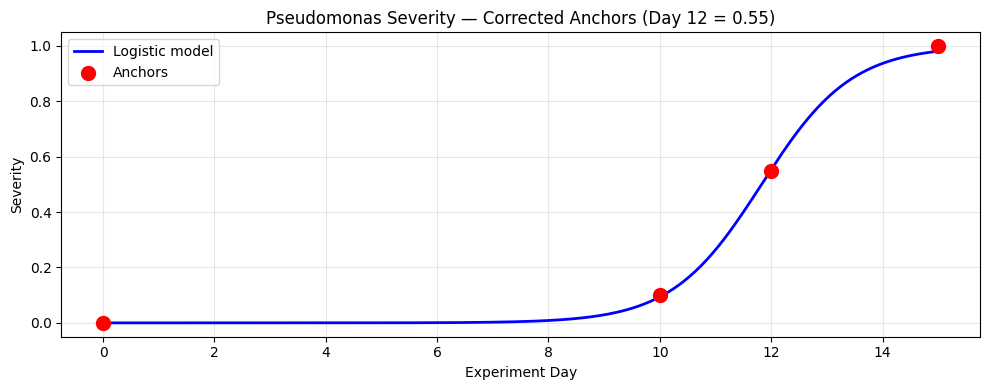

In [10]:
# Anchor points defining known severity levels at specific experiment days.
# Calibrated for Pseudomonas rapid-onset profile (Day 12 = 0.55).
DAYS_ANCHOR = np.array([0,     10,   12,   15   ])
SEVERITY_ANCHOR = np.array([0.001, 0.10, 0.55, 0.999])

# Initial parameter guess for logistic curve fitting: [growth_rate, midpoint].
INITIAL_PARAMS = [1, 12]

# Plot resolution: number of points along the time axis.
PLOT_RESOLUTION = 300
PLOT_DAY_MAX = 15


def logistic_fn(t, k, t0):
    """
    Compute the logistic (sigmoid) disease severity score for a given time.

    Parameters:
        t  (float | np.ndarray): Experiment day (integer or fractional).
        k  (float): Growth rate; controls steepness of the curve.
        t0 (float): Midpoint day; the day at which severity reaches 0.5.

    Returns:
        float | np.ndarray: Severity score in the range (0.0, 1.0).
    """
    return 1.0 / (1.0 + np.exp(-k * (t - t0)))


# Fit logistic curve to Pseudomonas-specific anchor points.
popt, _ = curve_fit(logistic_fn, DAYS_ANCHOR, SEVERITY_ANCHOR, p0=INITIAL_PARAMS)
K, T0 = popt
print(f'Logistic fit: k={K:.4f}, t0={T0:.4f}')

# Assign a single deterministic severity score per integer experiment day.
# Scores are clamped to [0.0, 1.0] and mapped onto the DataFrame directly.
day_severity = {
    d: float(np.clip(logistic_fn(d, K, T0), 0.0, 1.0))
    for d in sorted(df['experiment_day'].unique())
}
df['severity_score'] = df['experiment_day'].map(day_severity)

# Plot the fitted logistic curve alongside the calibration anchor points.
t_plot = np.linspace(0, PLOT_DAY_MAX, PLOT_RESOLUTION)
plt.figure(figsize=(10, 4))
plt.plot(
    t_plot, logistic_fn(t_plot, K, T0),
    'b-', lw=2, label='Logistic model'
)
plt.scatter(
    DAYS_ANCHOR, SEVERITY_ANCHOR,
    c='red', s=100, zorder=5, label='Anchors'
)
plt.title('Pseudomonas Severity — Corrected Anchors (Day 12 = 0.55)')
plt.xlabel('Experiment Day')
plt.ylabel('Severity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Patch Dataset

In [11]:
def select_evenly_spaced(group, n=10):
    group = group.sort_values('experiment_day')
    if len(group) <= n: return group
    return group.iloc[np.linspace(0, len(group)-1, n).astype(int)]

def split_day_images(group, n_train=7, n_unseen=3):
    group = group.sample(frac=1, random_state=42)
    train  = group.iloc[:n_train]
    unseen = group.iloc[n_train:n_train + n_unseen]
    return train, unseen

train_rows  = []
unseen_rows = []

for date, group in df.groupby('calendar_date'):
    tr, un = split_day_images(group, n_train=7, n_unseen=3)
    train_rows.append(tr)
    unseen_rows.append(un)

df_10          = pd.concat(train_rows).reset_index(drop=True)
df_unseen_real = pd.concat(unseen_rows).reset_index(drop=True)

print(f'Train: {len(df_10)} images')
print(f'Unseen: {len(df_unseen_real)} images')

print(df_10['calendar_date'].value_counts().sort_index())

# Build patch dataset — FIX #1: label = day_severity[integer_day]
all_patches, all_labels, all_days = [], [], []

# Also store sample patches per day for visualization
sample_patches_per_day = {}   # {experiment_day: [patch, patch, ...]}}

print('\nCreating patch dataset...')
for _, row in tqdm(df_10.iterrows(), total=len(df_10)):
    label = row['severity_score']
    img   = load_image(row)
    if img is None: continue
    patches = extract_patches(segment_leaf_only(img), green_threshold=0.50)
    for p in patches:
        all_patches.append(p)
        all_labels.append(label)
        all_days.append(row['experiment_day'])
    # Store daily samples (max 4 patches/day)
    day = row['experiment_day']
    if day not in sample_patches_per_day and patches:
        sample_patches_per_day[day] = patches[:4]

all_patches = np.array(all_patches, dtype=np.uint8)
all_labels  = np.array(all_labels,  dtype=np.float32)
all_days    = np.array(all_days,    dtype=np.int32)
print(f'Total patches: {len(all_patches)} | '
      f'Unique labels: {len(np.unique(all_labels))}')


Train: 84 images
Unseen: 36 images
calendar_date
01_11_2022    7
02_11_2022    7
03_11_2022    7
04_11_2022    7
05_11_2022    7
06_11_2022    7
07_11_2022    7
11_11_2022    7
12_11_2022    7
13_11_2022    7
14_11_2022    7
31_10_2022    7
Name: count, dtype: int64

Creating patch dataset...


100%|██████████| 84/84 [01:02<00:00,  1.34it/s]


Total patches: 91161 | Unique labels: 12


## 6. Patch Visualization — Sample Patches for Each Day

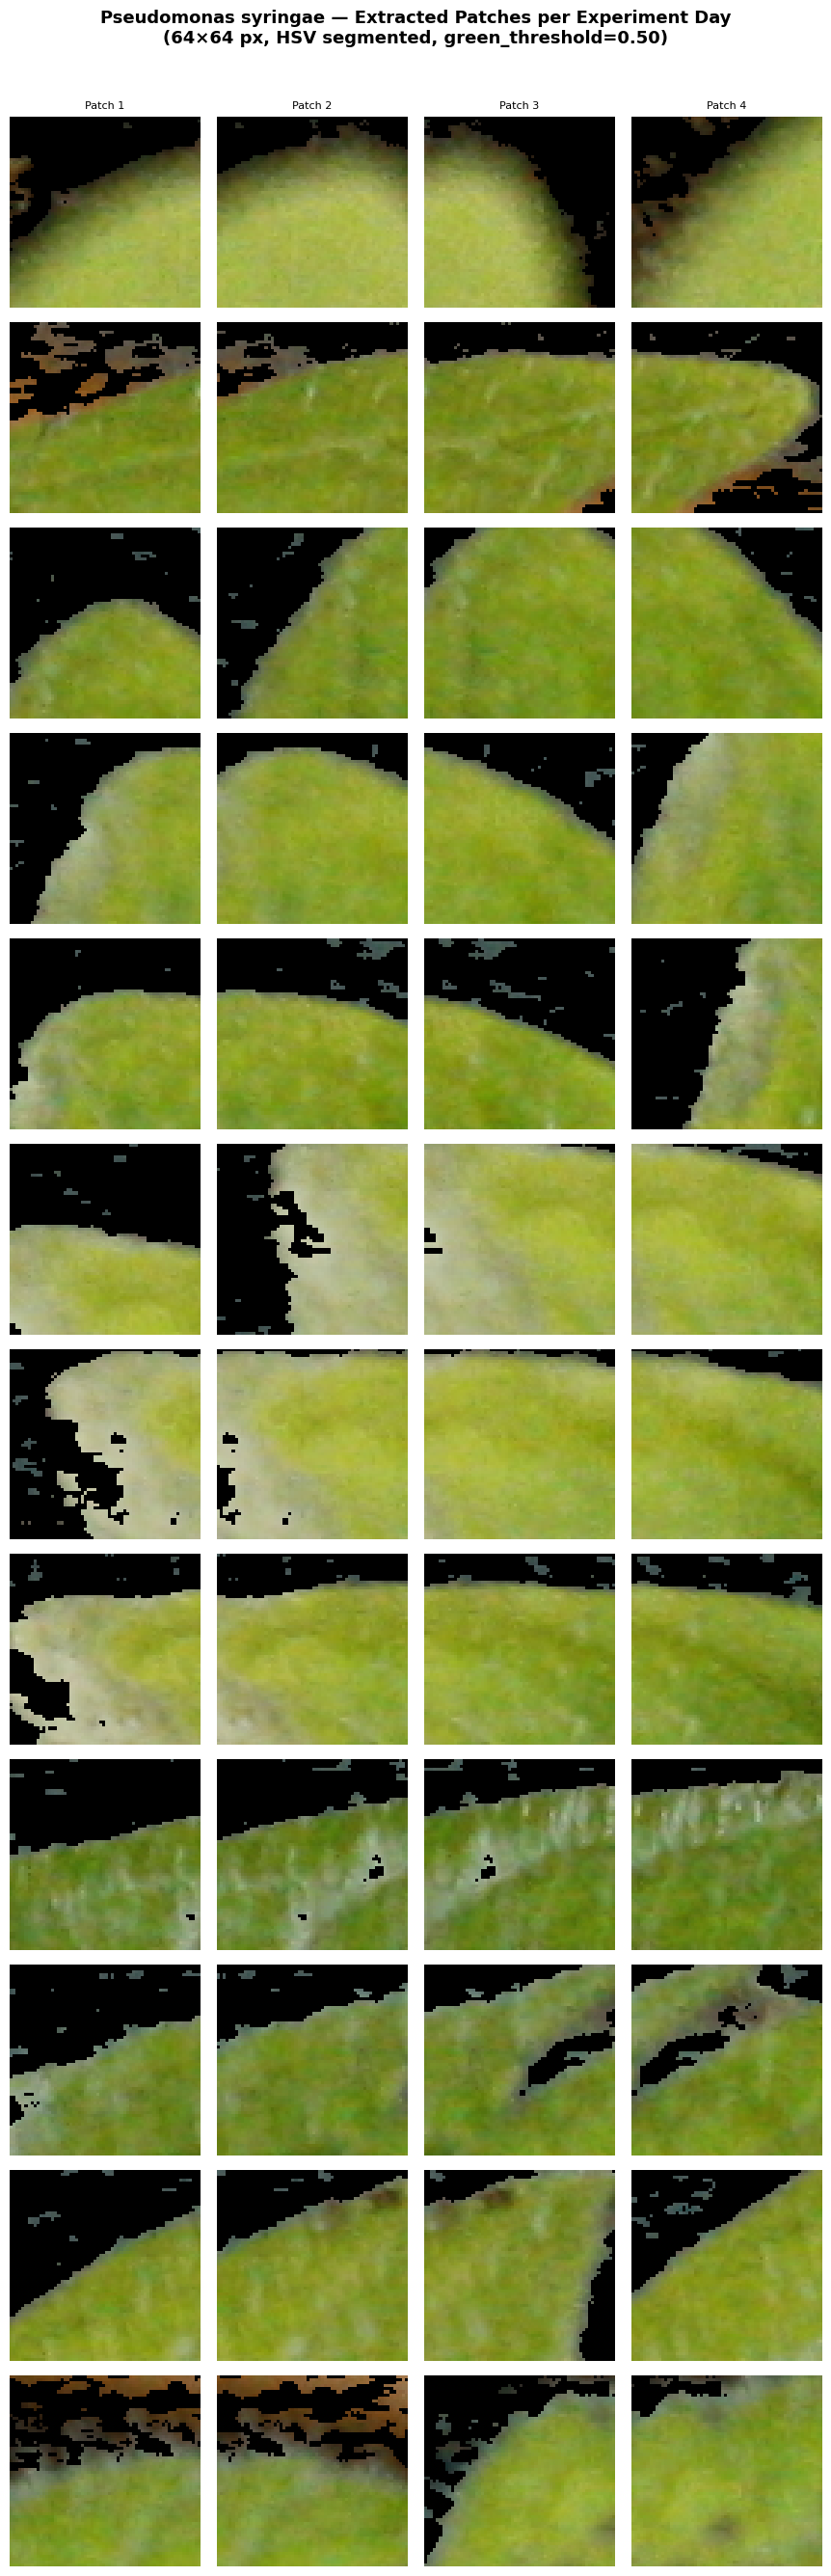

Saved: /content/drive/MyDrive/pseudomonas_patches_per_day.png


In [12]:
# Number of sample patches displayed per experiment day in the grid.
GRID_PATCHES_PER_DAY = 4

# DPI and subplot cell size for the patch visualisation figure.
GRID_CELL_SIZE = 2.2
GRID_SAVE_DPI = 120

# Output filename for the saved patch grid figure.
PATCH_GRID_FILENAME = 'pseudomonas_patches_per_day.png'


# Build sorted list of days and derive grid dimensions.
sorted_days = sorted(sample_patches_per_day.keys())
n_rows = len(sorted_days)
n_cols = GRID_PATCHES_PER_DAY

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * GRID_CELL_SIZE, n_rows * GRID_CELL_SIZE)
)
fig.suptitle(
    'Pseudomonas syringae — Extracted Patches per Experiment Day\n'
    '(64×64 px, HSV segmented, green_threshold=0.50)',
    fontsize=13, fontweight='bold', y=1.01
)

# Populate each grid cell with a sample patch or a blank placeholder.
for row_i, day in enumerate(sorted_days):
    patches = sample_patches_per_day[day]
    severity = day_severity[day]

    for col_i in range(n_cols):
        # Select correct axes depending on whether there is more than one row.
        ax = axes[row_i, col_i] if n_rows > 1 else axes[col_i]

        if col_i < len(patches):
            ax.imshow(patches[col_i])
        else:
            ax.set_facecolor('#f0f0f0')  # Blank placeholder for missing patches

        ax.axis('off')

        if col_i == 0:
            # Label the leftmost cell in each row with day and severity.
            ax.set_ylabel(
                f'Day {day}\n(sev={severity:.3f})',
                rotation=0, labelpad=55, fontsize=8, va='center'
            )

        if row_i == 0:
            ax.set_title(f'Patch {col_i + 1}', fontsize=8)

plt.tight_layout()

# Save the figure to Google Drive before displaying.
save_path = DRIVE + PATCH_GRID_FILENAME
plt.savefig(save_path, dpi=GRID_SAVE_DPI, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

## 7. Train/Val Split

Random patch-level split — ensuring the last days are not exclusively in validation.

In [13]:
# Fraction of patches held out for validation.
VALIDATION_SPLIT = 0.20

# DataLoader configuration constants.
BATCH_SIZE = 256
NUM_WORKERS = 2

# Fixed random seed for reproducible patch-level splitting.
RANDOM_SEED = 42

# Split patches randomly at patch level (not chronologically) to avoid
# the last experiment days falling entirely into the validation set.
X_tr, X_va, y_tr, y_va = train_test_split(
    all_patches, all_labels,
    test_size=VALIDATION_SPLIT,
    random_state=RANDOM_SEED
)

print(f'Train: {len(X_tr)} patches | Val: {len(X_va)} patches')
print(f'Train label range: [{y_tr.min():.3f}, {y_tr.max():.3f}]')
print(f'Val   label range: [{y_va.min():.3f}, {y_va.max():.3f}]')

# Initialise datasets and DataLoaders for training and validation.
ds_tr = FastRamDataset(X_tr, y_tr)
ds_va = FastRamDataset(X_va, y_va)

ld_tr = DataLoader(
    ds_tr, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
)
ld_va = DataLoader(
    ds_va, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

Train: 72928 patches | Val: 18233 patches
Train label range: [0.000, 0.937]
Val   label range: [0.000, 0.937]


In [14]:
# Fine-tuning hyperparameters.
FINETUNE_CNN_EPOCHS = 30
FINETUNE_CNN_LR = 1e-4
FINETUNE_CNN_PATIENCE = 8
FINETUNE_CNN_WEIGHT_DECAY = 1e-4
FINETUNE_CNN_GRAD_CLIP = 1.0

FINETUNE_LSTM_EPOCHS = 300
FINETUNE_LSTM_LR = 5e-3
FINETUNE_LSTM_LOG_INTERVAL = 100

# Pairwise ranking loss hyperparameters.
RANKING_MARGIN = 0.15
BCE_WEIGHT = 0.15
RANKING_MASK_THRESHOLD = 0.1

# Early stopping improvement threshold.
EARLY_STOP_MIN_DELTA = 1e-4


def eval_metrics(name, targets, preds):
    """
    Compute and print RMSE, MAE, and R² for a set of predictions.

    Parameters:
        name    (str): Display label for the evaluation split.
        targets (np.ndarray): Ground truth severity scores.
        preds   (np.ndarray): Predicted severity scores.

    Returns:
        tuple[float, float, float]: (rmse, mae, r2)
    """
    rmse = np.sqrt(mean_squared_error(targets, preds))
    mae = mean_absolute_error(targets, preds)
    r2 = r2_score(targets, preds)
    print(f'  {name:<48} RMSE={rmse:.5f}  MAE={mae:.5f}  R2={r2:.5f}')
    return rmse, mae, r2


def eval_cnn_loader(model, loader, name):
    """
    Evaluate CNN patch-level predictions over a DataLoader.

    Parameters:
        model  (nn.Module): Trained PatchSeverityNet model.
        loader (DataLoader): DataLoader for the target split.
        name   (str): Display label passed to eval_metrics.

    Returns:
        tuple[float, float, float]: (rmse, mae, r2)
    """
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for x, y in loader:
            x = NORMALIZE(x.to(DEVICE).float() / 255.0)
            preds.extend(torch.sigmoid(model(x)).cpu().numpy())
            targets.extend(y.numpy())

    return eval_metrics(name, np.array(targets), np.array(preds))


def pairwise_ranking_loss(preds_logits, targets,
                          margin=RANKING_MARGIN, bce_weight=BCE_WEIGHT):
    """
    Compute a combined pairwise ranking loss with a BCE anchor term.

    Encourages higher scores for more diseased patches. Falls back to
    BCE loss when no valid pairs exist in the batch.

    Parameters:
        preds_logits (torch.Tensor): Raw model output logits of shape (N,).
        targets      (torch.Tensor): Ground truth severity scores of shape (N,).
        margin       (float): Minimum required score gap between ranked pairs.
        bce_weight   (float): Weight applied to the BCE anchor loss term.

    Returns:
        torch.Tensor: Scalar combined loss value.
    """
    preds_probs = torch.sigmoid(preds_logits)

    # Compute pairwise differences for predictions and targets.
    diff_preds = preds_probs.unsqueeze(1) - preds_probs.unsqueeze(0)
    diff_targets = targets.unsqueeze(1) - targets.unsqueeze(0)

    # Consider only pairs with a meaningful target difference.
    mask = diff_targets > RANKING_MASK_THRESHOLD

    if not mask.any():
        return nn.BCEWithLogitsLoss()(preds_logits, targets)

    ranking_loss = torch.nn.functional.relu(
        margin - diff_preds[mask]
    ).mean()
    anchor_bce = nn.BCEWithLogitsLoss()(preds_logits, targets)

    return ranking_loss + (bce_weight * anchor_bce)


def finetune_cnn(source_path, label, epochs=FINETUNE_CNN_EPOCHS,
                 lr=FINETUNE_CNN_LR, patience=FINETUNE_CNN_PATIENCE):
    """
    Fine-tune a pre-trained PatchSeverityNet using pairwise ranking loss.

    Applies partial freezing (layer4 + fc trainable), mixed-precision
    training, gradient clipping, and early stopping on validation loss.

    Parameters:
        source_path (str): Path to the source CNN checkpoint.
        label       (str): Display label used in print output and plot title.
        epochs      (int): Maximum number of training epochs.
        lr          (float): Learning rate for the Adam optimiser.
        patience    (int): Early stopping patience in epochs.

    Returns:
        PatchSeverityNet: Fine-tuned model loaded with the best weights.
    """
    print(f'\n--- CNN Fine-Tuning: {label} ---')
    model = load_cnn(source_path, freeze_mode='partial')
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=FINETUNE_CNN_WEIGHT_DECAY
    )
    scaler = torch.amp.GradScaler('cuda')

    best_val = float('inf')
    best_state = None
    no_improve = 0
    train_history = []
    val_history = []

    for epoch in range(epochs):

        # Training phase.
        model.train()
        total_train_loss = 0
        for x, y in ld_tr:
            x = NORMALIZE(x.to(DEVICE, non_blocking=True).float() / 255.0)
            y = y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'):
                loss = pairwise_ranking_loss(model(x), y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), FINETUNE_CNN_GRAD_CLIP
            )
            scaler.step(optimizer)
            scaler.update()
            total_train_loss += loss.item()

        # Validation phase.
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for x, y in ld_va:
                x = NORMALIZE(x.to(DEVICE).float() / 255.0)
                with torch.amp.autocast('cuda'):
                    total_val_loss += pairwise_ranking_loss(
                        model(x), y.to(DEVICE)
                    ).item()

        avg_train = total_train_loss / len(ld_tr)
        avg_val = total_val_loss / len(ld_va)
        train_history.append(avg_train)
        val_history.append(avg_val)

        print(
            f'  Epoch {epoch + 1:02d}/{epochs} '
            f'| Train: {avg_train:.5f} | Val: {avg_val:.5f}'
        )

        # Early stopping: save best weights and track stagnation.
        if avg_val < best_val - EARLY_STOP_MIN_DELTA:
            best_val = avg_val
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(
                    f'  Early stopping at epoch {epoch + 1} '
                    f'| best val: {best_val:.5f}'
                )
                break

    model.load_state_dict(best_state)

    # Plot training and validation loss curves.
    plt.figure(figsize=(10, 3))
    plt.plot(train_history, label='Train')
    plt.plot(val_history, label='Val')
    plt.title(f'CNN Fine-Tuning Loss — {label}')
    plt.xlabel('Epoch')
    plt.ylabel('Pairwise Ranking Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return model


def build_lstm_tensors(cnn_scores, target_series_local):
    """
    Build LSTM input/target tensors from CNN daily score sequences.

    Uses only CNN scores as input features (input_size=1) to prevent
    leakage from temporal position encoding.

    Parameters:
        cnn_scores          (np.ndarray): Daily CNN severity scores of shape (T,).
        target_series_local (np.ndarray): Logistic target scores of shape (T,).

    Returns:
        tuple[torch.Tensor, torch.Tensor]: (X, y) tensors on DEVICE.
            X has shape (N, WINDOW, 1), y has shape (N,).
    """
    X, y = [], []
    for i in range(len(cnn_scores) - WINDOW):
        X.append(cnn_scores[i:i + WINDOW].reshape(-1, 1))
        y.append(target_series_local[i + WINDOW])
    return (
        torch.tensor(np.array(X), dtype=torch.float32).to(DEVICE),
        torch.tensor(np.array(y), dtype=torch.float32).to(DEVICE)
    )


def finetune_lstm(source_path, X_t, y_t, label,
                  epochs=FINETUNE_LSTM_EPOCHS, lr=FINETUNE_LSTM_LR):
    """
    Train a DenoiserLstm from scratch on the provided tensor sequences.

    Note: Weights from source_path are NOT loaded — the model trains
    from random initialisation to adapt fully to the new pathogen domain.

    Parameters:
        source_path (str): Unused path argument (kept for API consistency).
        X_t         (torch.Tensor): Input sequences of shape (N, WINDOW, 1).
        y_t         (torch.Tensor): Target scores of shape (N,).
        label       (str): Display label used in print output.
        epochs      (int): Number of training epochs.
        lr          (float): Learning rate for the Adam optimiser.

    Returns:
        tuple[DenoiserLstm, np.ndarray]: (trained_model, predictions)
    """
    print(f'\n--- LSTM Fine-Tuning: {label} ---')

    model = DenoiserLstm(
        input_size=LSTM_INPUT_SIZE, hidden_size=LSTM_HIDDEN_SIZE
    ).to(DEVICE)

    # All parameters are trainable — no frozen layers for scratch training.
    for param in model.parameters():
        param.requires_grad = True

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_t), y_t)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % FINETUNE_LSTM_LOG_INTERVAL == 0:
            print(f'  Epoch {epoch + 1:03d} | Loss: {loss.item():.6f}')

    # Run inference on the training tensors after training completes.
    model.eval()
    with torch.no_grad():
        preds = model(X_t).cpu().numpy()

    return model, preds


def compute_daily_scores(cnn_model, df_src, label):
    """
    Score each image in a DataFrame and aggregate to daily mean CNN scores.

    Parameters:
        cnn_model (nn.Module): Trained PatchSeverityNet for scoring.
        df_src    (pd.DataFrame): DataFrame with image rows to score.
        label     (str): Display label shown during progress output.

    Returns:
        pd.DataFrame: Daily aggregated scores with columns:
                      ['experiment_day', 'cnn_score', 'severity_score'].
    """
    print(f'Computing daily CNN scores: {label}')
    df_src = df_src.copy()
    df_src['cnn_score'] = 0.0

    for idx, row in tqdm(df_src.iterrows(), total=len(df_src)):
        img = load_image(row)
        if img is None:
            continue
        df_src.at[idx, 'cnn_score'] = score_image(img, cnn_model)

    # Aggregate per-image scores to daily mean and first logistic score.
    daily = (
        df_src.groupby('experiment_day')
        .agg(
            cnn_score=('cnn_score', 'mean'),
            severity_score=('severity_score', 'first')
        )
        .reset_index()
        .sort_values('experiment_day')
    )
    return daily


print('Helper functions defined.')

Helper functions defined.


## 9. Pipeline A — 20-patch Xanthomonas Transfer Learning


--- CNN Fine-Tuning: 20-patch TL ---
  cnn_sensor_base_model_20.pth | trainable=8,394,241/11,177,025 (75.1%)
  Epoch 01/10 | Train: 0.03573 | Val: 0.01862
  Epoch 02/10 | Train: 0.01476 | Val: 0.01670
  Epoch 03/10 | Train: 0.01291 | Val: 0.01659
  Epoch 04/10 | Train: 0.01211 | Val: 0.01600
  Epoch 05/10 | Train: 0.01163 | Val: 0.01630
  Epoch 06/10 | Train: 0.01154 | Val: 0.01526
  Epoch 07/10 | Train: 0.01139 | Val: 0.01551
  Epoch 08/10 | Train: 0.01110 | Val: 0.01389
  Epoch 09/10 | Train: 0.01081 | Val: 0.01470
  Epoch 10/10 | Train: 0.01095 | Val: 0.01379


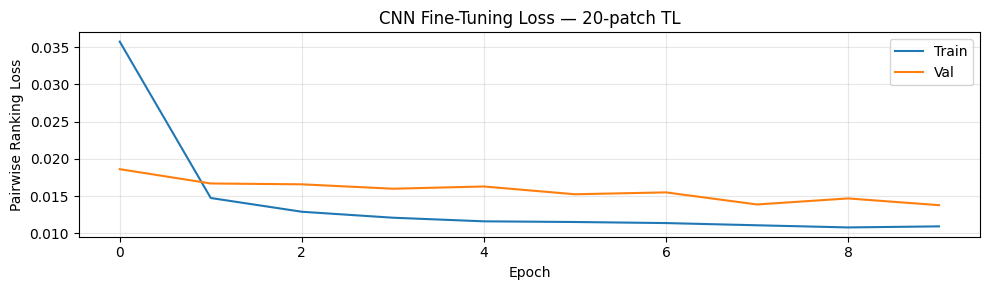


CNN Patch Metrics (20-patch TL):
  CNN-20TL TRAIN                                   RMSE=0.02984  MAE=0.01027  R2=0.97481
  CNN-20TL VAL                                     RMSE=0.05126  MAE=0.01638  R2=0.92258
Computing daily CNN scores: 20-patch TL


100%|██████████| 84/84 [01:28<00:00,  1.05s/it]



--- LSTM Fine-Tuning: 20-patch TL ---
  Epoch 100 | Loss: 0.019076
  Epoch 200 | Loss: 0.006870
  Epoch 300 | Loss: 0.007829

=== 20-patch TL — Train Set ===
  CNN-20TL  (train)                                RMSE=0.03730  MAE=0.02471  R2=0.98937
  Hybrid-20TL (train)                              RMSE=0.08175  MAE=0.04699  R2=0.94893


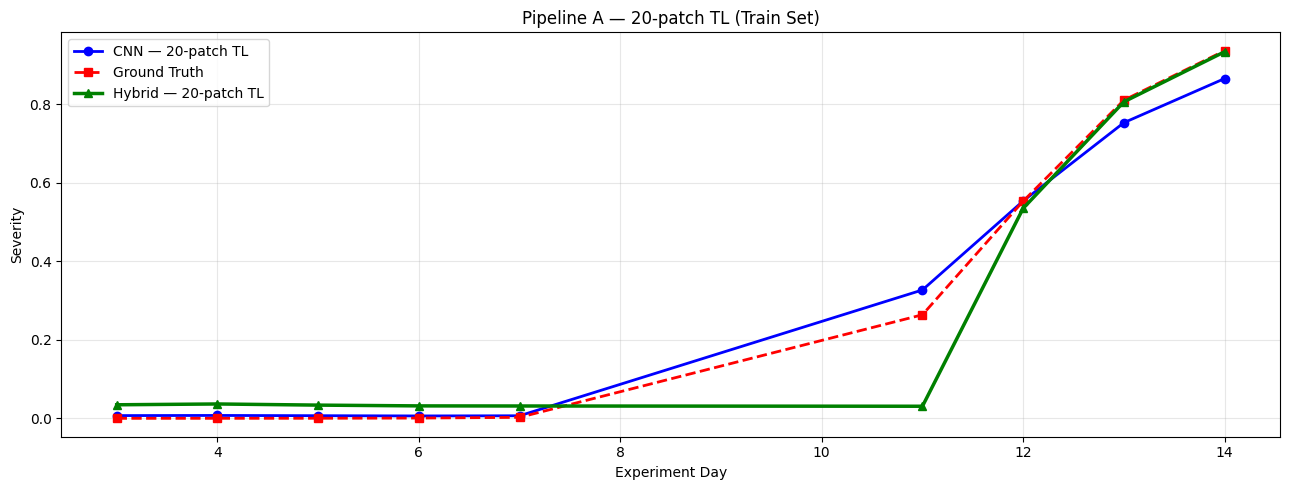

Saved: cnn_pseudo_20tl.pth | lstm_pseudo_20tl.pth


In [15]:
# Saved checkpoint filenames for the 20-patch transfer learning pipeline.
CNN_20_SAVE_FILENAME = 'cnn_pseudo_20tl.pth'
LSTM_20_SAVE_FILENAME = 'lstm_pseudo_20tl.pth'

# Fine-tuning overrides for the 20-patch CNN pipeline.
CNN_20_EPOCHS = 10

# Fine-tune the CNN on the 20-patch transfer learning source checkpoint.
cnn_20 = finetune_cnn(
    CNN_20_PATH, label='20-patch TL',
    epochs=CNN_20_EPOCHS,
    lr=FINETUNE_CNN_LR,
    patience=FINETUNE_CNN_PATIENCE
)

# Evaluate fine-tuned CNN on training and validation patch sets.
print('\nCNN Patch Metrics (20-patch TL):')
r_cnn20_tr = eval_cnn_loader(cnn_20, ld_tr, 'CNN-20TL TRAIN')
r_cnn20_va = eval_cnn_loader(cnn_20, ld_va, 'CNN-20TL VAL')

# Compute per-image CNN scores and aggregate to daily means.
daily_20 = compute_daily_scores(cnn_20, df_10, '20-patch TL')
cnn_series_20 = daily_20['cnn_score'].values.astype(np.float32)
target_ser_20 = daily_20['severity_score'].values.astype(np.float32)
plot_time_20 = daily_20['experiment_day'].values[WINDOW:]

# Build LSTM input tensors and fine-tune using its own target series.
X_20, y_20 = build_lstm_tensors(cnn_series_20, target_ser_20)
lstm_20, hybrid_20_train = finetune_lstm(
    LSTM_20_PATH, X_20, y_20, '20-patch TL'
)

# Align plot arrays to the same length by offsetting by WINDOW.
plot_cnn_20 = cnn_series_20[WINDOW:]
plot_target_20 = target_ser_20[WINDOW:]

# Evaluate both CNN and hybrid predictions against ground truth.
print('\n=== 20-patch TL — Train Set ===')
r_20_cnn = eval_metrics('CNN-20TL  (train)', plot_target_20, plot_cnn_20)
r_20_hybrid = eval_metrics('Hybrid-20TL (train)', plot_target_20, hybrid_20_train)

# Plot CNN observation, ground truth, and hybrid prediction over time.
plt.figure(figsize=(13, 5))
plt.plot(
    plot_time_20, plot_cnn_20,
    'b-o', lw=2, label='CNN — 20-patch TL'
)
plt.plot(
    plot_time_20, plot_target_20,
    'r--s', lw=2, label='Ground Truth'
)
plt.plot(
    plot_time_20, hybrid_20_train,
    'g-^', lw=2.5, label='Hybrid — 20-patch TL'
)
plt.title('Pipeline A — 20-patch TL (Train Set)')
plt.xlabel('Experiment Day')
plt.ylabel('Severity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Persist fine-tuned model weights to Google Drive.
torch.save(cnn_20.state_dict(), DRIVE + CNN_20_SAVE_FILENAME)
torch.save(lstm_20.state_dict(), DRIVE + LSTM_20_SAVE_FILENAME)
print(f'Saved: {CNN_20_SAVE_FILENAME} | {LSTM_20_SAVE_FILENAME}')

## 10. Pipeline B — 10-patch Xanthomonas Transfer Learning


--- CNN Fine-Tuning: 10-patch TL ---
  cnn_sensor_base_model_10.pth | trainable=8,394,241/11,177,025 (75.1%)
  Epoch 01/10 | Train: 0.02951 | Val: 0.01528
  Epoch 02/10 | Train: 0.01357 | Val: 0.01370
  Epoch 03/10 | Train: 0.01226 | Val: 0.01366
  Epoch 04/10 | Train: 0.01171 | Val: 0.01386
  Epoch 05/10 | Train: 0.01147 | Val: 0.01358
  Epoch 06/10 | Train: 0.01127 | Val: 0.01405
  Epoch 07/10 | Train: 0.01106 | Val: 0.01318
  Epoch 08/10 | Train: 0.01079 | Val: 0.01304
  Epoch 09/10 | Train: 0.01089 | Val: 0.01272
  Epoch 10/10 | Train: 0.01095 | Val: 0.01324


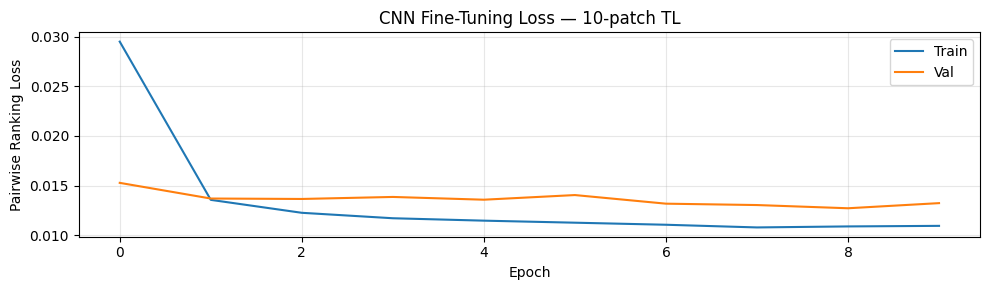


CNN Patch Metrics (10-patch TL):
  CNN-10TL TRAIN                                   RMSE=0.02425  MAE=0.00683  R2=0.98337
  CNN-10TL VAL                                     RMSE=0.03822  MAE=0.00983  R2=0.95696
Computing daily CNN scores: 10-patch TL


100%|██████████| 84/84 [01:28<00:00,  1.05s/it]



--- LSTM Fine-Tuning: 10-patch TL ---
  Epoch 100 | Loss: 0.006366
  Epoch 200 | Loss: 0.006954
  Epoch 300 | Loss: 0.006668

=== 10-patch TL — Train Set ===
  CNN-10TL  (train)                                RMSE=0.03779  MAE=0.02451  R2=0.98909
  Hybrid-10TL (train)                              RMSE=0.08097  MAE=0.04870  R2=0.94990


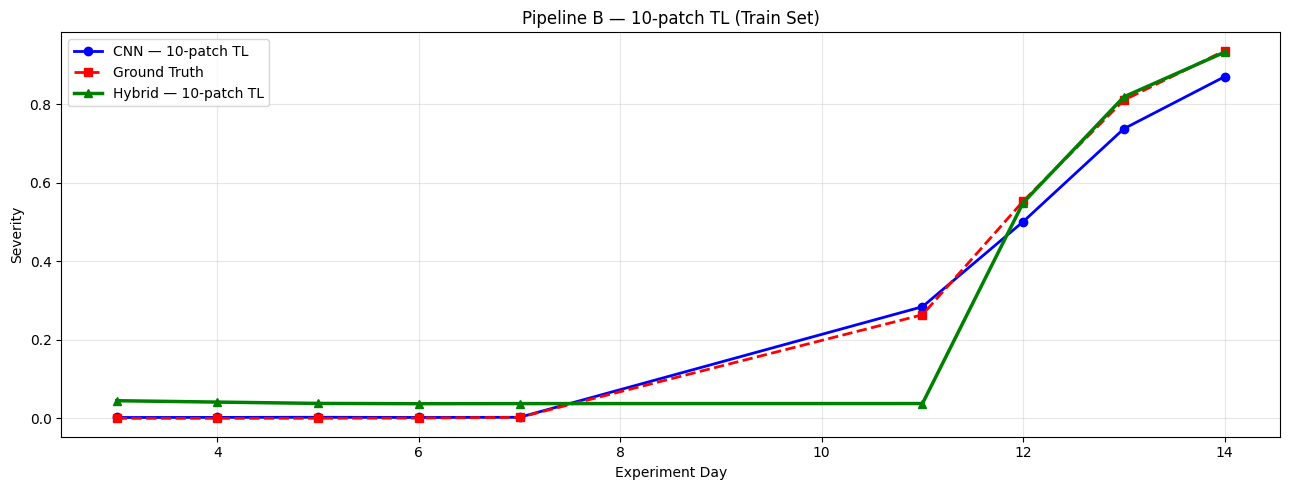

Saved: cnn_pseudo_10tl.pth | lstm_pseudo_10tl.pth


In [16]:
# Saved checkpoint filenames for the 10-patch transfer learning pipeline.
CNN_10_SAVE_FILENAME = 'cnn_pseudo_10tl.pth'
LSTM_10_SAVE_FILENAME = 'lstm_pseudo_10tl.pth'

# Fine-tuning epoch override for the 10-patch CNN pipeline.
CNN_10_EPOCHS = 10

# Fine-tune the CNN on the 10-patch transfer learning source checkpoint.
cnn_10 = finetune_cnn(
    CNN_10_PATH, label='10-patch TL',
    epochs=CNN_10_EPOCHS,
    lr=FINETUNE_CNN_LR,
    patience=FINETUNE_CNN_PATIENCE
)

# Evaluate fine-tuned CNN on training and validation patch sets.
print('\nCNN Patch Metrics (10-patch TL):')
r_cnn10_tr = eval_cnn_loader(cnn_10, ld_tr, 'CNN-10TL TRAIN')
r_cnn10_va = eval_cnn_loader(cnn_10, ld_va, 'CNN-10TL VAL')

# Compute per-image CNN scores and aggregate to daily means.
daily_10 = compute_daily_scores(cnn_10, df_10, '10-patch TL')
cnn_series_10 = daily_10['cnn_score'].values.astype(np.float32)
target_ser_10 = daily_10['severity_score'].values.astype(np.float32)
plot_time_10 = daily_10['experiment_day'].values[WINDOW:]

# Build LSTM input tensors and fine-tune using its own target series.
X_10, y_10 = build_lstm_tensors(cnn_series_10, target_ser_10)
lstm_10, hybrid_10_train = finetune_lstm(
    LSTM_10_PATH, X_10, y_10, '10-patch TL'
)

# Align plot arrays to the same length by offsetting by WINDOW.
plot_cnn_10 = cnn_series_10[WINDOW:]
plot_target_10 = target_ser_10[WINDOW:]

# Evaluate both CNN and hybrid predictions against ground truth.
print('\n=== 10-patch TL — Train Set ===')
r_10_cnn = eval_metrics('CNN-10TL  (train)', plot_target_10, plot_cnn_10)
r_10_hybrid = eval_metrics('Hybrid-10TL (train)', plot_target_10, hybrid_10_train)

# Plot CNN observation, ground truth, and hybrid prediction over time.
plt.figure(figsize=(13, 5))
plt.plot(
    plot_time_10, plot_cnn_10,
    'b-o', lw=2, label='CNN — 10-patch TL'
)
plt.plot(
    plot_time_10, plot_target_10,
    'r--s', lw=2, label='Ground Truth'
)
plt.plot(
    plot_time_10, hybrid_10_train,
    'g-^', lw=2.5, label='Hybrid — 10-patch TL'
)
plt.title('Pipeline B — 10-patch TL (Train Set)')
plt.xlabel('Experiment Day')
plt.ylabel('Severity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Persist fine-tuned model weights to Google Drive.
torch.save(cnn_10.state_dict(), DRIVE + CNN_10_SAVE_FILENAME)
torch.save(lstm_10.state_dict(), DRIVE + LSTM_10_SAVE_FILENAME)
print(f'Saved: {CNN_10_SAVE_FILENAME} | {LSTM_10_SAVE_FILENAME}')

## 11. Train Set — Comparative Graph

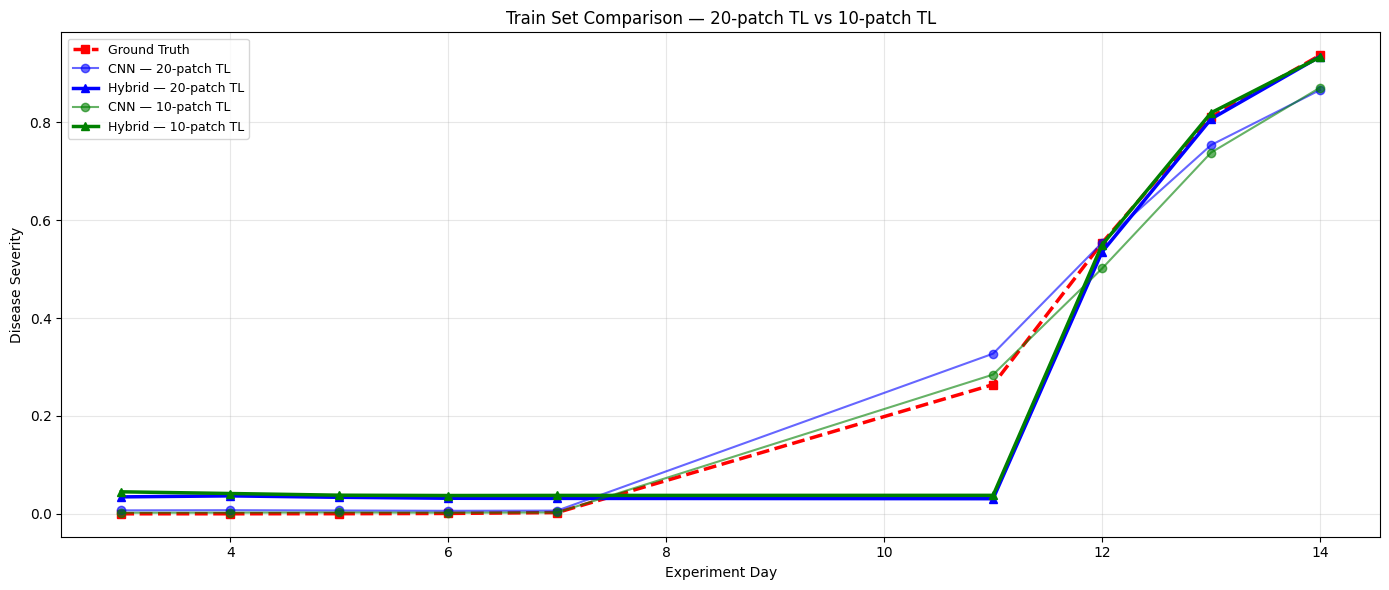

In [17]:
# Ground truth is shared across both pipelines (same logistic day mapping).
# Both series are plotted on a single axis for direct visual comparison.
plt.figure(figsize=(14, 6))

plt.plot(
    plot_time_20, plot_target_20,
    'r--s', lw=2.5, label='Ground Truth'
)
plt.plot(
    plot_time_20, plot_cnn_20,
    'b-o', lw=1.5, alpha=0.6, label='CNN — 20-patch TL'
)
plt.plot(
    plot_time_20, hybrid_20_train,
    'b-^', lw=2.5, label='Hybrid — 20-patch TL'
)
plt.plot(
    plot_time_10, plot_cnn_10,
    'g-o', lw=1.5, alpha=0.6, label='CNN — 10-patch TL'
)
plt.plot(
    plot_time_10, hybrid_10_train,
    'g-^', lw=2.5, label='Hybrid — 10-patch TL'
)

plt.title('Train Set Comparison — 20-patch TL vs 10-patch TL')
plt.xlabel('Experiment Day')
plt.ylabel('Disease Severity')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Unseen Data Evaluation

In [ ]:
# Copy unseen evaluation set to avoid modifying the original DataFrame.
df_test = df_unseen_real.copy()
print(f'Unseen test images: {len(df_test)}')
print(df_test['experiment_day'].value_counts().sort_index())


def unseen_eval(cnn_model, lstm_model, label):
    """
    Evaluate CNN and hybrid model performance on the unseen test set.

    Scores each unseen image with the CNN, aggregates scores to daily
    means, then runs LSTM inference over sliding windows. Returns both
    metric tuples and aligned arrays for downstream plotting.

    Parameters:
        cnn_model  (nn.Module): Fine-tuned PatchSeverityNet for scoring.
        lstm_model (nn.Module): Fine-tuned DenoiserLstm for denoising.
        label      (str): Display label used in print output.

    Returns:
        tuple:
            - metrics: tuple((rmse, mae, r2), (rmse, mae, r2)) for CNN and
                       hybrid, or None if unseen days <= WINDOW.
            - plot_data: tuple(u_time, u_cnn_cropped, u_hybrid, y_true),
                         or None if unseen days <= WINDOW.
    """
    # Aggregate unseen set to one row per experiment day.
    df_u = (
        df_test.groupby('experiment_day')
        .agg(
            severity_score=('severity_score', 'first'),
            calendar_date=('calendar_date', 'first')
        )
        .reset_index()
        .sort_values('experiment_day')
    )
    df_u['cnn_score'] = 0.0

    # Score each image in the group and store the daily mean CNN score.
    for day, group in df_test.groupby('experiment_day'):
        scores = [
            score_image(load_image(row), cnn_model)
            for _, row in group.iterrows()
            if load_image(row) is not None
        ]
        df_u.loc[df_u['experiment_day'] == day, 'cnn_score'] = (
            np.mean(scores) if scores else 0.0
        )

    u_cnn = df_u['cnn_score'].values.astype(np.float32)
    u_target = df_u['severity_score'].values.astype(np.float32)

    # Skip LSTM inference if there are not enough days to form one window.
    if len(u_cnn) <= WINDOW:
        print(f'[{label}] Unseen days <= WINDOW — skipping LSTM inference.')
        return None, None

    # Build LSTM input tensors using CNN scores only (no time index).
    x_unseen = torch.tensor(
        np.array([
            u_cnn[i:i + WINDOW].reshape(-1, 1)
            for i in range(len(u_cnn) - WINDOW)
        ]),
        dtype=torch.float32
    ).to(DEVICE)

    # Run LSTM inference on the unseen CNN score sequence.
    lstm_model.eval()
    with torch.no_grad():
        u_hybrid = lstm_model(x_unseen).cpu().numpy()

    # Align arrays to the same length by offsetting by WINDOW.
    y_true = u_target[WINDOW:]
    u_cnn_cropped = u_cnn[WINDOW:]
    u_time = df_u['experiment_day'].values[WINDOW:]

    print(f'\n=== {label} — Unseen Data ===')
    r_cnn = eval_metrics(f'CNN    [{label}] unseen', y_true, u_cnn_cropped)
    r_hybrid = eval_metrics(f'Hybrid [{label}] unseen', y_true, u_hybrid)

    return (r_cnn, r_hybrid), (u_time, u_cnn_cropped, u_hybrid, y_true)


# Evaluate both transfer learning pipelines on the unseen test set.
res_20, data_20 = unseen_eval(cnn_20, lstm_20, '20-patch TL')
res_10, data_10 = unseen_eval(cnn_10, lstm_10, '10-patch TL')

Unseen test images: 36
experiment_day
0     3
1     3
2     3
3     3
4     3
5     3
6     3
7     3
11    3
12    3
13    3
14    3
Name: count, dtype: int64

=== 20-patch TL — Unseen Data ===
  CNN    [20-patch TL] unseen                      RMSE=0.05586  MAE=0.03584  R2=0.97616
  Hybrid [20-patch TL] unseen                      RMSE=0.08642  MAE=0.05401  R2=0.94293


In [ ]:
# Imports for zero-shot model construction (may already be in scope).
from torchvision import models
import torch.nn as nn


class PatchSeverityNetZeroShot(nn.Module):
    """
    ResNet-18 regression model for zero-shot cross-pathogen evaluation.

    Identical architecture to PatchSeverityNet but initialised without
    ImageNet weights, intended to be loaded from a saved Xanthomonas
    checkpoint without any fine-tuning on Pseudomonas data.
    """

    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        # Replace classification head with a single regression output.
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, 1)

    def forward(self, x):
        return self.backbone(x).squeeze(1)  # Output shape: (batch,)


def load_zero_shot_pair(cnn_path, lstm_path):
    """
    Load a CNN and LSTM checkpoint pair for zero-shot evaluation.

    No fine-tuning is applied — weights are loaded directly from the
    Xanthomonas source checkpoints and models are set to eval mode.

    Parameters:
        cnn_path  (str): Path to the Xanthomonas CNN checkpoint.
        lstm_path (str): Path to the Xanthomonas LSTM checkpoint.

    Returns:
        tuple[PatchSeverityNetZeroShot, DenoiserLstm]:
            (cnn_model, lstm_model) both in eval mode on DEVICE.
    """
    cnn_model = PatchSeverityNetZeroShot().to(DEVICE)
    cnn_model.load_state_dict(torch.load(cnn_path, map_location=DEVICE))
    cnn_model.eval()

    lstm_model = DenoiserLstm(
        input_size=LSTM_INPUT_SIZE, hidden_size=LSTM_HIDDEN_SIZE
    ).to(DEVICE)
    lstm_model.load_state_dict(torch.load(lstm_path, map_location=DEVICE))
    lstm_model.eval()

    return cnn_model, lstm_model


# Zero-shot evaluation: Xanthomonas models applied to Pseudomonas data.
print("=== ZERO-SHOT EVALUATION ===")
print("Xanthomonas CNN + LSTM → Pseudomonas (no fine-tuning)\n")

# Load and evaluate the 20-patch Xanthomonas base model pair.
cnn_xa20_zs, lstm_xa20_zs = load_zero_shot_pair(CNN_20_PATH, LSTM_20_PATH)
res_zs20, data_zs20 = unseen_eval(cnn_xa20_zs, lstm_xa20_zs, 'Zero-shot Xa-20')

# Load and evaluate the 10-patch Xanthomonas base model pair.
cnn_xa10_zs, lstm_xa10_zs = load_zero_shot_pair(CNN_10_PATH, LSTM_10_PATH)
res_zs10, data_zs10 = unseen_eval(cnn_xa10_zs, lstm_xa10_zs, 'Zero-shot Xa-10')

## 13. Unseen — Comparative Graph

In [ ]:
if data_20 is not None and data_10 is not None:

    # Unpack aligned plot arrays for both transfer learning pipelines.
    time_20, cnn_20_unseen, hybrid_20_unseen, ground_truth_20 = data_20
    time_10, cnn_10_unseen, hybrid_10_unseen, ground_truth_10 = data_10

    # Plot CNN observations, hybrid predictions, and ground truth for both
    # pipelines on a single axis for direct visual comparison.
    plt.figure(figsize=(14, 6))
    plt.plot(
        time_20, ground_truth_20,
        'r--s', lw=2.5, label='Ground Truth'
    )
    plt.plot(
        time_20, cnn_20_unseen,
        'b-o', lw=1.5, alpha=0.6, label='CNN — 20-patch TL'
    )
    plt.plot(
        time_20, hybrid_20_unseen,
        'b-^', lw=2.5, label='Hybrid — 20-patch TL'
    )
    plt.plot(
        time_10, cnn_10_unseen,
        'g-o', lw=1.5, alpha=0.6, label='CNN — 10-patch TL'
    )
    plt.plot(
        time_10, hybrid_10_unseen,
        'g-^', lw=2.5, label='Hybrid — 10-patch TL'
    )
    plt.title('Unseen Data — 20-patch TL vs 10-patch TL')
    plt.xlabel('Experiment Day')
    plt.ylabel('Disease Severity')
    plt.legend(fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print('Not enough unseen days to form an LSTM window — plot skipped.')

## 14. Summary Table — 20-patch TL vs 10-patch TL

In [ ]:
# Decimal precision for rounded metric values in the summary table.
METRIC_DECIMAL_PLACES = 5

# Width constants for the summary table separator lines.
TABLE_WIDTH = 72
DIVIDER_NAME_WIDTH = 48
DIVIDER_METRIC_WIDTH = 7

# Accumulated rows for the final metric summary DataFrame.
summary_rows = []


def add_row(name, targets, preds):
    """
    Compute metrics and append a result row to the summary table.

    Parameters:
        name    (str): Display label for the model and split combination.
        targets (np.ndarray): Ground truth severity scores.
        preds   (np.ndarray): Predicted severity scores.
    """
    summary_rows.append({
        'Model / Split': name,
        'RMSE': round(np.sqrt(mean_squared_error(targets, preds)),
                      METRIC_DECIMAL_PLACES),
        'MAE': round(mean_absolute_error(targets, preds),
                     METRIC_DECIMAL_PLACES),
        'R2': round(r2_score(targets, preds), METRIC_DECIMAL_PLACES)
    })


# Add 20-patch transfer learning results for train and unseen splits.
add_row('20-patch TL | CNN            — Train', plot_target_20, plot_cnn_20)
add_row('20-patch TL | Hybrid CNN+LSTM — Train', plot_target_20, hybrid_20_train)

if data_20 is not None:
    time_20, cnn_20_unseen, hybrid_20_unseen, ground_truth_20 = data_20
    add_row('20-patch TL | CNN            — Unseen',
            ground_truth_20, cnn_20_unseen)
    add_row('20-patch TL | Hybrid CNN+LSTM — Unseen',
            ground_truth_20, hybrid_20_unseen)

# Insert a visual separator row between pipeline sections.
summary_rows.append({
    'Model / Split': '─' * DIVIDER_NAME_WIDTH,
    'RMSE': '─' * DIVIDER_METRIC_WIDTH,
    'MAE': '─' * DIVIDER_METRIC_WIDTH,
    'R2': '─' * DIVIDER_METRIC_WIDTH
})

# Add 10-patch transfer learning results for train and unseen splits.
add_row('10-patch TL | CNN            — Train', plot_target_10, plot_cnn_10)
add_row('10-patch TL | Hybrid CNN+LSTM — Train', plot_target_10, hybrid_10_train)

if data_10 is not None:
    time_10, cnn_10_unseen, hybrid_10_unseen, ground_truth_10 = data_10
    add_row('10-patch TL | CNN            — Unseen',
            ground_truth_10, cnn_10_unseen)
    add_row('10-patch TL | Hybrid CNN+LSTM — Unseen',
            ground_truth_10, hybrid_10_unseen)

# Print the consolidated metric summary table.
df_summary = pd.DataFrame(summary_rows)
print('\n' + '=' * TABLE_WIDTH)
print('FULL METRIC SUMMARY — Pseudomonas syringae Transfer Learning')
print('          20-patch TL  vs  10-patch TL')
print('=' * TABLE_WIDTH)
print(df_summary.to_string(index=False))
print('=' * TABLE_WIDTH)

In [ ]:
# Width of the section separator lines in the summary output.
SUMMARY_DIVIDER_WIDTH = 31

print("=== Dataset Metrics Summary ===")

print("--- Raw Data ---")
print(f"Total original images found   : {len(df)}")
print(
    f"Date range                    : "
    f"{df['datetime'].min().date()} to {df['datetime'].max().date()}"
)
print(f"Total unique experiment days  : {df['experiment_day'].nunique()}")
print(f"Images per label:\n{df['label'].value_counts().to_string()}")
print("-" * SUMMARY_DIVIDER_WIDTH)

print("--- Processed Data ---")
print(f"Training images (train/val)   : {len(df_10)}")
print(f"Unseen test images            : {len(df_unseen_real)}")
print(f"Total extracted patches       : {len(all_patches)}")
print(f"Training patches shape (X_tr) : {X_tr.shape}")
print(f"Validation patches shape (X_va): {X_va.shape}")
print("-" * SUMMARY_DIVIDER_WIDTH)

print("--- Severity Labels ---")
print(f"Unique severity labels        : {len(np.unique(all_labels))}")
print(
    f"Severity label range          : "
    f"[{all_labels.min():.3f}, {all_labels.max():.3f}]"
)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Number of images per experiment day
sns.countplot(data=df, x='experiment_day', hue='experiment_day', ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Number of Raw Images per Experiment Day')
axes[0].set_xlabel('Experiment Day')
axes[0].set_ylabel('Image Count')

# Plot 2: Number of images per severity label
sns.countplot(data=df, y='label', hue='label', ax=axes[1], palette='magma', order=df['label'].value_counts().index, legend=False)
axes[1].set_title('Number of Raw Images per Severity Label')
axes[1].set_xlabel('Image Count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Number of sample images displayed per label row.
SAMPLES_PER_LABEL = 4

# Fixed random seed for reproducible label sampling.
RANDOM_SEED = 42

# Build sorted list of unique labels and derive grid dimensions.
unique_labels = sorted(df['label'].unique())
n_cols = SAMPLES_PER_LABEL
n_rows = len(unique_labels)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
fig.suptitle('Sample Images per Severity Label', fontsize=16, y=1.02)

# Populate each row with random sample images for the corresponding label.
for row_idx, label in enumerate(unique_labels):
    label_df = df[df['label'] == label]

    # Sample up to SAMPLES_PER_LABEL images for this label.
    sample_rows = label_df.sample(
        n=min(n_cols, len(label_df)), random_state=RANDOM_SEED
    )

    for col_idx, (_, row) in enumerate(sample_rows.iterrows()):
        ax = axes[row_idx, col_idx] if n_rows > 1 else axes[col_idx]
        img = load_image(row)

        if img is not None:
            ax.imshow(img)
        else:
            # Display an error placeholder if the image cannot be loaded.
            ax.text(0.5, 0.5, 'Image Load Error', ha='center', va='center')

        ax.axis('off')

        if col_idx == 0:
            # Label the leftmost cell in each row with the severity class.
            ax.set_title(label, loc='left', fontsize=12, pad=10)

plt.tight_layout()
plt.show()